![Screenshot 2026-05-17 162002.png](<attachment:Screenshot 2026-05-17 162002.png>)
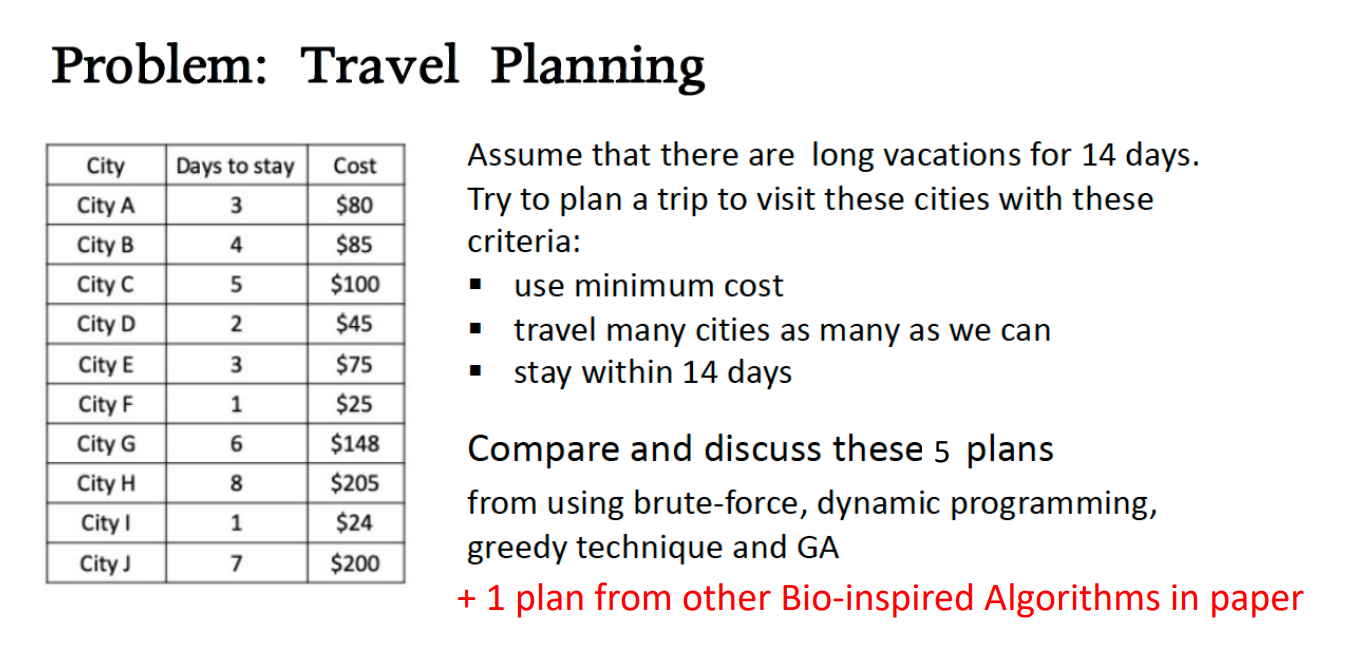

## Dynamic Programming

ส่วนนี้ใช้แนวคิด Dynamic Programming เพื่อแก้โจทย์เลือกเมืองภายใต้ข้อจำกัดจำนวนวันไม่เกิน 14 วัน โดยมองโจทย์คล้ายปัญหา 0/1 Knapsack คือแต่ละเมืองเลือกได้ครั้งเดียวหรือไม่เลือกก็ได้

การทำงานของโค้ด:
- สร้างตาราง `dp` ขนาด `max_days + 1` เพื่อเก็บคำตอบที่ดีที่สุดของจำนวนวันแต่ละค่า
- แต่ละช่องใน `dp` เก็บข้อมูล 3 อย่าง คือ จำนวนเมืองที่เลือกได้, ค่าใช้จ่ายรวม และรายชื่อเมืองที่เลือก
- วนดูเมืองทีละเมือง แล้วพิจารณาว่าถ้าเลือกเมืองนั้นเพิ่มเข้าไป จำนวนวันรวมยังไม่เกินกำหนดหรือไม่
- วนจำนวนวันแบบถอยหลัง เพื่อป้องกันไม่ให้เมืองเดียวกันถูกเลือกซ้ำในรอบเดียว
- ถ้าแผนใหม่เลือกเมืองได้มากกว่าแผนเดิม จะอัปเดตค่าในตารางทันที
- ถ้าจำนวนเมืองเท่ากัน จะเลือกแผนที่มีค่าใช้จ่ายรวมน้อยกว่า
- ผลลัพธ์สุดท้ายคืนค่าจาก `dp[max_days]` ซึ่งเป็นแผนที่ดีที่สุดภายใต้จำนวนวันสูงสุดที่กำหนด

ข้อดีของวิธีนี้คือให้คำตอบที่เหมาะสมที่สุดสำหรับข้อมูลชุดนี้ เพราะพิจารณาทางเลือกอย่างเป็นระบบ ไม่ได้ตัดสินใจจากเมืองใดเมืองหนึ่งทันที

In [1]:
def solve_travel_dp(cities, max_days=14):
    # เริ่มต้นสร้างตารางบันทึกสถานะ
    dp = [(0, 0, []) for _ in range(max_days + 1)] # (จำนวนเมือง, ค่าใช้จ่ายรวม, รายชื่อเมืองที่เลือก)
    
    # วนลูปเพื่อดึงข้อมูลเมืองทีละเมือง
    for city, info in cities.items():
        days = info['days']  # จำนวนวันของเมืองนั้น
        cost = info['cost']  # ค่าใช้จ่ายของเมืองนั้น
        
        # วนลูปถอยหลังป้องกันการเลือกซ้ำ
        for w in range(max_days, days - 1, -1):
            prev_cities, prev_cost, prev_list = dp[w - days]
            
            new_cities = prev_cities + 1  # เพิ่มจำนวนเมืองที่เลือก
            new_cost = prev_cost + cost   # เพิ่มค่าใช้จ่ายรวม
            new_list = prev_list + [city] # เพิ่มชื่อเมืองที่เลือกเข้าไปในลิสต์
            
            curr_cities, curr_cost, curr_list = dp[w]
            
            # ตรวจสอบแผนการเดินทางที่ดีที่สุด
            if new_cities > curr_cities:
                dp[w] = (new_cities, new_cost, new_list) # เลือกแผนที่มีจำนวนเมืองมากกว่า
            elif new_cities == curr_cities:
                if new_cost < curr_cost: 
                    dp[w] = (new_cities, new_cost, new_list) # หากจำนวนเมืองเท่ากัน เลือกแผนที่มีค่าใช้จ่ายต่ำกว่า
                    
    return dp[max_days]

In [2]:
cities_data = {
    "City A": {"days": 3, "cost": 80},
    "City B": {"days": 4, "cost": 85},
    "City C": {"days": 5, "cost": 100},
    "City D": {"days": 2, "cost": 45},
    "City E": {"days": 3, "cost": 75},
    "City F": {"days": 1, "cost": 25},
    "City G": {"days": 6, "cost": 148},
    "City H": {"days": 8, "cost": 205},
    "City I": {"days": 1, "cost": 24},
    "City J": {"days": 7, "cost": 200}
}

In [3]:
max_cities, min_cost, chosen_cities = solve_travel_dp(cities_data)

print("Dynamic Programming")
print(f"จำนวนเมืองที่เก็บได้มากที่สุด: {max_cities} เมือง")
print(f"ค่าใช้จ่ายรวมต่ำสุด: ${min_cost}")
print(f"เมืองที่เลือกไป: {', '.join(chosen_cities)}")
print(f"จำนวนวันรวมที่ใช้: {sum(cities_data[c]['days'] for c in chosen_cities)} วัน")

Dynamic Programming
จำนวนเมืองที่เก็บได้มากที่สุด: 6 เมือง
ค่าใช้จ่ายรวมต่ำสุด: $334
เมืองที่เลือกไป: City A, City B, City D, City E, City F, City I
จำนวนวันรวมที่ใช้: 14 วัน


## Greedy Technique

ส่วนนี้ใช้แนวคิด Greedy Algorithm คือเลือกคำตอบที่ดูดีที่สุดในแต่ละขั้นตอนทันที โดยไม่ย้อนกลับไปแก้การเลือกก่อนหน้า

การทำงานของโค้ด:
- แปลงข้อมูลเมืองให้อยู่ในรูปแบบลิสต์ โดยแต่ละรายการมีชื่อเมือง จำนวนวัน และค่าใช้จ่าย
- เรียงลำดับเมืองจากจำนวนวันที่ใช้น้อยไปมาก
- ถ้าจำนวนวันเท่ากัน จะเรียงจากค่าใช้จ่ายน้อยไปมาก
- วนเลือกเมืองตามลำดับที่เรียงไว้
- ถ้าเพิ่มเมืองนั้นแล้วจำนวนวันรวมยังไม่เกิน `max_days` จะเลือกเมืองนั้นทันที
- อัปเดตจำนวนวันรวม ค่าใช้จ่ายรวม และรายชื่อเมืองที่เลือก
- คืนค่าจำนวนเมืองทั้งหมด ค่าใช้จ่ายรวม และรายชื่อเมืองที่ถูกเลือก

วิธี Greedy ทำงานเร็วและเข้าใจง่าย แต่ไม่ได้รับประกันว่าจะได้คำตอบที่ดีที่สุดเสมอ เพราะการเลือกจากตัวเลือกที่ดีที่สุดเฉพาะหน้าอาจทำให้พลาดชุดคำตอบที่ดีกว่าในภาพรวม

In [4]:
def solve_travel_greedy(cities, max_days=14):
    cities_list = [(name, info['days'], info['cost']) for name, info in cities.items()]
    
    #เรียงลำดับตามจำนวนวัน (น้อย->มาก) หากเท่ากันให้เรียงตามราคา (น้อย->มาก)
    cities_list.sort(key=lambda x: (x[1], x[2]))
    
    chosen_cities = [] # รายชื่อเมืองที่เลือก
    total_days = 0 # จำนวนวันรวมที่ใช้
    total_cost = 0 # ค่าใช้จ่ายรวมที่ต้องจ่าย
    
    for name, days, cost in cities_list:
        # หากบวกวันเพิ่มแล้วยังไม่เกิน 14 วัน ให้ตัดสินใจเลือกเมืองนั้นทันที
        if total_days + days <= max_days:
            chosen_cities.append(name) # เพิ่มชื่อเมืองที่เลือกเข้าไปในลิสต์ chosen_cities
            total_days += days # บวกจำนวนวันของเมืองนั้นเข้าไปใน total_days
            total_cost += cost # บวกค่าใช้จ่ายของเมืองนั้นเข้าไปใน total_cost
            
    return len(chosen_cities), total_cost, chosen_cities

In [5]:
cities_data = {
    "City A": {"days": 3, "cost": 80},
    "City B": {"days": 4, "cost": 85},
    "City C": {"days": 5, "cost": 100},
    "City D": {"days": 2, "cost": 45},
    "City E": {"days": 3, "cost": 75},
    "City F": {"days": 1, "cost": 25},
    "City G": {"days": 6, "cost": 148},
    "City H": {"days": 8, "cost": 205},
    "City I": {"days": 1, "cost": 24},
    "City J": {"days": 7, "cost": 200}
}

In [6]:
max_cities, min_cost, chosen_cities = solve_travel_greedy(cities_data)

print("Greedy Technique")
print(f"จำนวนเมืองที่เก็บได้มากที่สุด: {max_cities} เมือง")
print(f"ค่าใช้จ่ายรวมต่ำสุด: ${min_cost}")
print(f"เมืองที่เลือกไป: {', '.join(chosen_cities)}")
print(f"จำนวนวันรวมที่ใช้: {sum(cities_data[c]['days'] for c in chosen_cities)} วัน")

Greedy Technique
จำนวนเมืองที่เก็บได้มากที่สุด: 6 เมือง
ค่าใช้จ่ายรวมต่ำสุด: $334
เมืองที่เลือกไป: City I, City F, City D, City E, City A, City B
จำนวนวันรวมที่ใช้: 14 วัน


## Genetic Algorithm (GA)

ส่วนนี้อ้างอิงจากไฟล์ `lecture10_Genetic_Algorithm.pdf` ซึ่งอธิบายแนวคิด Genetic Algorithm ผ่านคำว่า Genotype และ Phenotype

การนำมาใช้กับโจทย์นี้:
- Genotype คือ chromosome แบบเลขฐานสอง โดยแต่ละตำแหน่งแทนเมืองหนึ่งเมือง
- ค่า 1 หมายถึงเลือกเมืองนั้น และค่า 0 หมายถึงไม่เลือกเมืองนั้น
- Phenotype คือแผนการเดินทางจริงที่ได้จากการถอดรหัส chromosome ว่าเลือกเมืองใดบ้าง
- Fitness ใช้วัดคุณภาพของคำตอบ โดยให้ความสำคัญกับการเลือกจำนวนเมืองให้มากที่สุดก่อน แล้วจึงพิจารณาค่าใช้จ่ายรวมให้น้อยที่สุด

การทำงานของโค้ด:
- สร้างประชากรเริ่มต้น หรือ initial population โดยสุ่ม chromosome หลายชุด
- ตรวจสอบและซ่อม chromosome ด้วย `repair_chromosome` ถ้าจำนวนวันรวมเกิน 14 วัน
- ประเมินคำตอบแต่ละชุดด้วย `evaluate_plan`
- เลือกพ่อแม่ด้วย tournament selection โดยสุ่มผู้เข้าแข่งขันหลายตัวแล้วเลือกตัวที่ fitness ดีที่สุด
- สร้างลูกด้วย crossover โดยตัด chromosome ที่จุดหนึ่งแล้วสลับส่วนของพ่อแม่
- ทำ mutation โดยสุ่มกลับค่า gene บางตำแหน่งจาก 0 เป็น 1 หรือ 1 เป็น 0
- ใช้ elitism เพื่อเก็บคำตอบที่ดีที่สุดไว้ในแต่ละรุ่น
- เมื่อครบจำนวน generation จะคืนค่าแผนที่ดีที่สุดที่พบ

วิธี GA เหมาะกับโจทย์ที่มีทางเลือกจำนวนมาก เพราะสามารถค้นหาคำตอบที่ดีโดยไม่ต้องลองทุกกรณีแบบ brute force

In [7]:
import random

def evaluate_plan(chromosome, city_names, cities, max_days=14):
    chosen_cities = [city_names[i] for i, gene in enumerate(chromosome) if gene == 1]
    total_days = sum(cities[city]['days'] for city in chosen_cities)
    total_cost = sum(cities[city]['cost'] for city in chosen_cities)

    if total_days > max_days:
        over_days = total_days - max_days
        return -1000 - (over_days * 100) - total_cost, 0, total_cost, []

    # Main goal: maximize cities. Secondary goal: minimize cost.
    fitness = (len(chosen_cities) * 1000) - total_cost
    return fitness, len(chosen_cities), total_cost, chosen_cities

def repair_chromosome(chromosome, city_names, cities, max_days=14):
    chromosome = chromosome[:]

    while True:
        chosen_index = [i for i, gene in enumerate(chromosome) if gene == 1]
        total_days = sum(cities[city_names[i]]['days'] for i in chosen_index)

        if total_days <= max_days:
            break

        remove_index = max(chosen_index, key=lambda i: (cities[city_names[i]]['days'], cities[city_names[i]]['cost']))
        chromosome[remove_index] = 0

    return chromosome

def tournament_selection(population, city_names, cities, max_days=14, tournament_size=3):
    candidates = random.sample(population, tournament_size)
    return max(candidates, key=lambda chromosome: evaluate_plan(chromosome, city_names, cities, max_days)[0])

def crossover(parent1, parent2):
    if len(parent1) <= 1:
        return parent1[:], parent2[:]

    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

def mutate(chromosome, mutation_rate=0.05):
    return [1 - gene if random.random() < mutation_rate else gene for gene in chromosome]

def solve_travel_ga(cities, max_days=14, population_size=40, generations=100, mutation_rate=0.05, seed=42):
    random.seed(seed)
    city_names = list(cities.keys())
    chromosome_length = len(city_names)

    population = [
        repair_chromosome(
            [random.randint(0, 1) for _ in range(chromosome_length)],
            city_names,
            cities,
            max_days
        )
        for _ in range(population_size)
    ]

    greedy_order = sorted(range(chromosome_length), key=lambda i: (cities[city_names[i]]['days'], cities[city_names[i]]['cost']))
    greedy_chromosome = [0] * chromosome_length
    greedy_days = 0
    for index in greedy_order:
        city = city_names[index]
        if greedy_days + cities[city]['days'] <= max_days:
            greedy_chromosome[index] = 1
            greedy_days += cities[city]['days']

    population[0] = greedy_chromosome
    best_chromosome = max(population, key=lambda chromosome: evaluate_plan(chromosome, city_names, cities, max_days)[0])

    for _ in range(generations):
        new_population = [best_chromosome[:]]

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, city_names, cities, max_days)
            parent2 = tournament_selection(population, city_names, cities, max_days)

            child1, child2 = crossover(parent1, parent2)
            child1 = repair_chromosome(mutate(child1, mutation_rate), city_names, cities, max_days)
            child2 = repair_chromosome(mutate(child2, mutation_rate), city_names, cities, max_days)

            new_population.append(child1)
            if len(new_population) < population_size:
                new_population.append(child2)

        population = new_population
        current_best = max(population, key=lambda chromosome: evaluate_plan(chromosome, city_names, cities, max_days)[0])

        best_score = evaluate_plan(best_chromosome, city_names, cities, max_days)
        current_score = evaluate_plan(current_best, city_names, cities, max_days)

        if (current_score[1] > best_score[1]) or (current_score[1] == best_score[1] and current_score[2] < best_score[2]):
            best_chromosome = current_best[:]

    _, max_cities, min_cost, chosen_cities = evaluate_plan(best_chromosome, city_names, cities, max_days)
    return max_cities, min_cost, chosen_cities

In [8]:
max_cities, min_cost, chosen_cities = solve_travel_ga(cities_data)

print("Genetic Algorithm (GA)")
print(f"จำนวนเมืองที่เก็บได้มากที่สุด: {max_cities} เมือง")
print(f"ค่าใช้จ่ายรวมต่ำสุด: ${min_cost}")
print(f"เมืองที่เลือกไป: {', '.join(chosen_cities)}")
print(f"จำนวนวันรวมที่ใช้: {sum(cities_data[c]['days'] for c in chosen_cities)} วัน")

Genetic Algorithm (GA)
จำนวนเมืองที่เก็บได้มากที่สุด: 6 เมือง
ค่าใช้จ่ายรวมต่ำสุด: $334
เมืองที่เลือกไป: City A, City B, City D, City E, City F, City I
จำนวนวันรวมที่ใช้: 14 วัน


## Bio-inspired Algorithm (Binary Particle Swarm Optimization)

ส่วนนี้อ้างอิงจากสไลด์ mini project ใน `lecture10_Genetic_Algorithm.pdf` ที่กำหนดให้เพิ่มอีก 1 แผนจาก Bio-inspired Algorithms ใน paper

ใน notebook นี้เลือกใช้ Binary Particle Swarm Optimization หรือ BPSO ซึ่งเป็นอัลกอริทึมที่ได้แรงบันดาลใจจากการเคลื่อนที่เป็นฝูง โดยปรับให้เหมาะกับโจทย์แบบเลือกหรือไม่เลือกเมือง

การนำมาใช้กับโจทย์นี้:
- Particle position คือแผนเลือกเมืองแบบ binary เช่นเดียวกับ GA
- ค่า 1 หมายถึงเลือกเมือง และค่า 0 หมายถึงไม่เลือกเมือง
- Velocity คือแนวโน้มที่ particle จะเลือกหรือไม่เลือกเมืองในแต่ละตำแหน่ง
- Personal best คือคำตอบที่ดีที่สุดที่ particle ตัวนั้นเคยพบ
- Global best คือคำตอบที่ดีที่สุดที่ทั้งฝูงเคยพบ

การทำงานของโค้ด:
- สร้างกลุ่ม particle เริ่มต้นแบบสุ่ม
- ตรวจสอบและซ่อมคำตอบที่จำนวนวันเกิน 14 วัน
- เก็บคำตอบที่ดีที่สุดของแต่ละ particle เป็น personal best
- หา global best จากคำตอบที่ดีที่สุดของทั้งกลุ่ม
- อัปเดต velocity โดยใช้ข้อมูลจากตำแหน่งเดิม personal best และ global best
- ใช้ sigmoid แปลง velocity ให้เป็นความน่าจะเป็นในการเลือกเมือง
- อัปเดตตำแหน่งของ particle เป็นค่า 0 หรือ 1
- ทำซ้ำหลายรอบจนได้แผนที่ดีที่สุดที่ค้นพบ

วิธี BPSO เป็นอีกแนวทาง Bio-inspired ที่ใช้การเรียนรู้ร่วมกันของหลายคำตอบ เพื่อค่อย ๆ เคลื่อนเข้าใกล้แผนการเดินทางที่ดีขึ้น

In [9]:
import random
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def solve_travel_bpso(cities, max_days=14, swarm_size=30, iterations=100, w=0.72, c1=1.49, c2=1.49, seed=42):
    random.seed(seed)
    city_names = list(cities.keys())
    dimensions = len(city_names)

    particles = []
    velocities = []

    for _ in range(swarm_size):
        particle = repair_chromosome(
            [random.randint(0, 1) for _ in range(dimensions)],
            city_names,
            cities,
            max_days
        )
        particles.append(particle)
        velocities.append([random.uniform(-1, 1) for _ in range(dimensions)])

    greedy_order = sorted(range(dimensions), key=lambda i: (cities[city_names[i]]['days'], cities[city_names[i]]['cost']))
    greedy_particle = [0] * dimensions
    greedy_days = 0
    for index in greedy_order:
        city = city_names[index]
        if greedy_days + cities[city]['days'] <= max_days:
            greedy_particle[index] = 1
            greedy_days += cities[city]['days']

    particles[0] = greedy_particle
    personal_best = [particle[:] for particle in particles]
    global_best = max(personal_best, key=lambda particle: evaluate_plan(particle, city_names, cities, max_days)[0])

    for _ in range(iterations):
        for i in range(swarm_size):
            for d in range(dimensions):
                r1 = random.random()
                r2 = random.random()
                velocities[i][d] = (
                    w * velocities[i][d]
                    + c1 * r1 * (personal_best[i][d] - particles[i][d])
                    + c2 * r2 * (global_best[d] - particles[i][d])
                )

                if random.random() < sigmoid(velocities[i][d]):
                    particles[i][d] = 1
                else:
                    particles[i][d] = 0

            particles[i] = repair_chromosome(particles[i], city_names, cities, max_days)

            current_score = evaluate_plan(particles[i], city_names, cities, max_days)
            personal_score = evaluate_plan(personal_best[i], city_names, cities, max_days)

            if (current_score[1] > personal_score[1]) or (current_score[1] == personal_score[1] and current_score[2] < personal_score[2]):
                personal_best[i] = particles[i][:]

        current_global = max(personal_best, key=lambda particle: evaluate_plan(particle, city_names, cities, max_days)[0])
        current_global_score = evaluate_plan(current_global, city_names, cities, max_days)
        global_score = evaluate_plan(global_best, city_names, cities, max_days)

        if (current_global_score[1] > global_score[1]) or (current_global_score[1] == global_score[1] and current_global_score[2] < global_score[2]):
            global_best = current_global[:]

    _, max_cities, min_cost, chosen_cities = evaluate_plan(global_best, city_names, cities, max_days)
    return max_cities, min_cost, chosen_cities

In [10]:
max_cities, min_cost, chosen_cities = solve_travel_bpso(cities_data)

print("Bio-inspired Algorithm (Binary PSO)")
print(f"จำนวนเมืองที่เก็บได้มากที่สุด: {max_cities} เมือง")
print(f"ค่าใช้จ่ายรวมต่ำสุด: ${min_cost}")
print(f"เมืองที่เลือกไป: {', '.join(chosen_cities)}")
print(f"จำนวนวันรวมที่ใช้: {sum(cities_data[c]['days'] for c in chosen_cities)} วัน")

Bio-inspired Algorithm (Binary PSO)
จำนวนเมืองที่เก็บได้มากที่สุด: 6 เมือง
ค่าใช้จ่ายรวมต่ำสุด: $334
เมืองที่เลือกไป: City A, City B, City D, City E, City F, City I
จำนวนวันรวมที่ใช้: 14 วัน
